In [1]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.path.dirname('gmm_utils'), '..')))

from src.utils.gmm_utils import GMMDataset, GMMImageDataset
import matplotlib.pyplot as plt
import torchvision.utils

In [2]:
def plot_samples(samples, title="GMM Samples"):
    plt.figure(figsize=(5, 5))
    samples_np = samples.cpu().numpy()
    plt.scatter(samples_np[:, 0], samples_np[:, 1], alpha=0.5, s=2)
    plt.title(title)
    plt.grid(True)
    plt.show()

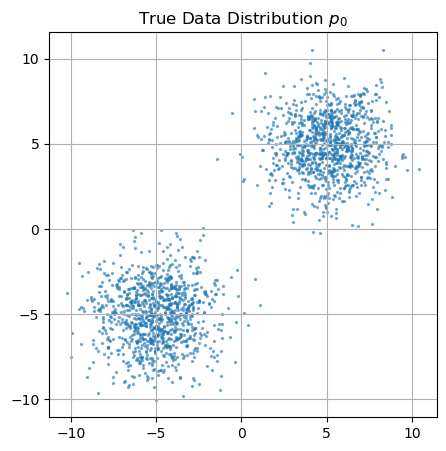

In [3]:
# Example usage for your project:
if __name__ == "__main__":
    # Define a mixture of two Gaussians
    # Mode 1: centered at (-3, -3), Mode 2: centered at (3, 3)
    means = [[-5.0, -5.0], [5.0, 5.0]]
    sigmas = [3, 3] # Isotropic variances
    
    dataset = GMMDataset(means, sigmas)
    batch, _ = dataset.sample(2000)
    plot_samples(batch, "True Data Distribution $p_0$")

In [4]:
batch_size = 64
image_size = 32

image_dataset = GMMImageDataset(dataset, image_size)

In [5]:
batch = image_dataset.sample_as_images(batch_size)

In [6]:
batch.size()

torch.Size([64, 4, 32, 32])

In [7]:
batch[0]

tensor([[[0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
          0.0000e+00, 0.0000e+00],
         [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
          0.0000e+00, 0.0000e+00],
         [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
          0.0000e+00, 0.0000e+00],
         ...,
         [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
          0.0000e+00, 0.0000e+00],
         [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
          0.0000e+00, 0.0000e+00],
         [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
          0.0000e+00, 0.0000e+00]],

        [[9.2096e-11, 2.7163e-10, 7.5260e-10,  ..., 3.6839e-08,
          1.7737e-08, 8.0225e-09],
         [3.2251e-10, 9.5121e-10, 2.6355e-09,  ..., 1.2900e-07,
          6.2113e-08, 2.8094e-08],
         [1.0610e-09, 3.1292e-09, 8.6702e-09,  ..., 4.2439e-07,
          2.0433e-07, 9.2422e-08],
         ...,
         [5.3558e-06, 1.5797e-05, 4.3767e-05,  ..., 2.1423e-03,
          1.031

In [20]:
def display_gmm_heatmaps_v2(batch_tensor, nrow=8, padding=4):
    """
    Displays GMM heatmaps with clear spacing between images.
    """
    # Increase padding for more space. 
    # pad_value=1.0 will make the lines between images 'hot' (white/yellow) 
    # in the hot colormap, or white in grayscale.
    grid = torchvision.utils.make_grid(
        batch_tensor, 
        nrow=nrow, 
        padding=padding, 
        pad_value=0.5 # Mid-gray padding
    )
    
    # Extract one channel for colormap visualization
    for i in range(grid.size(0)):
        grid_single_channel = grid[i].cpu().numpy() 
        
        plt.figure(figsize=(12, 12))
        plt.imshow(grid_single_channel, cmap='hot')
        plt.colorbar(label="Intensity")
        plt.title(f"GMM Heatmap Grid Channel = {i} (Padding={padding})")
        plt.axis('off')
        plt.show()

    

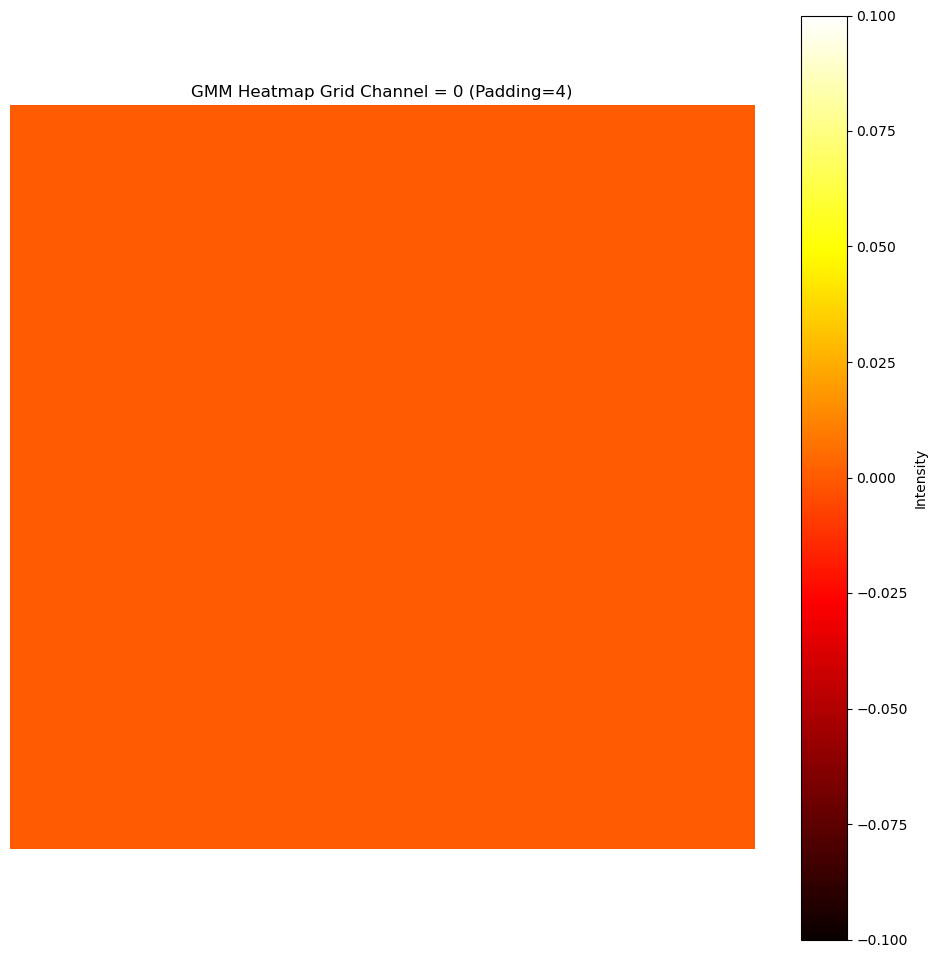

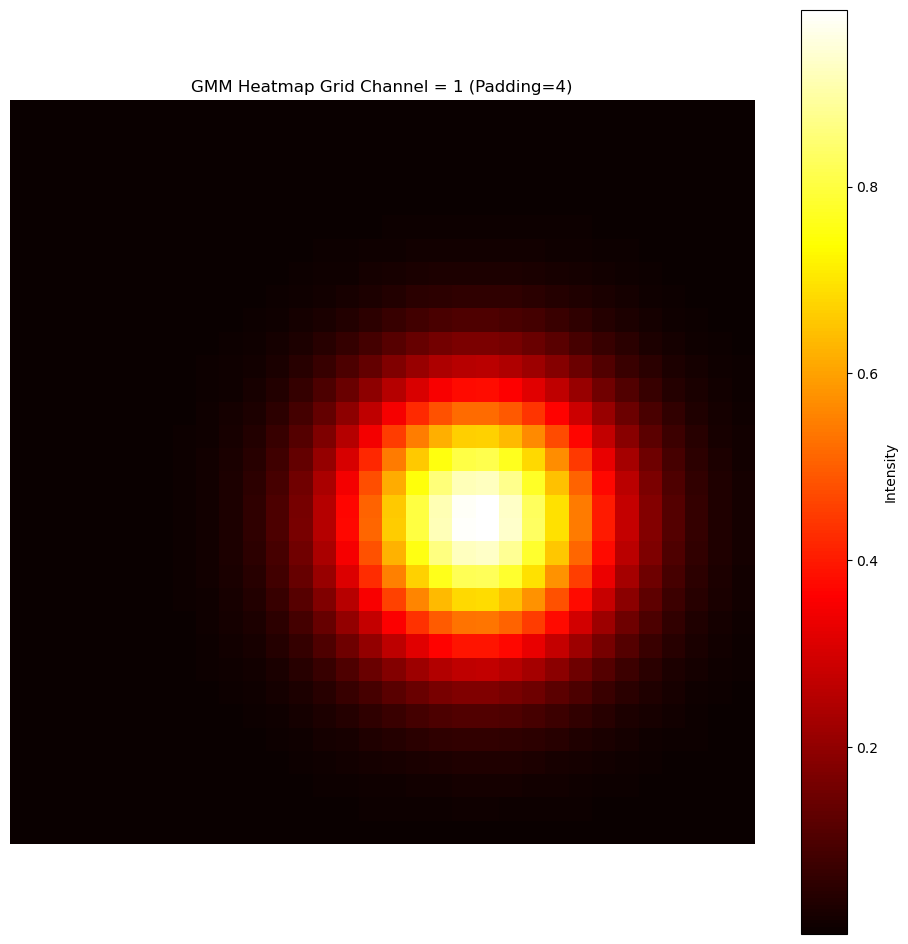

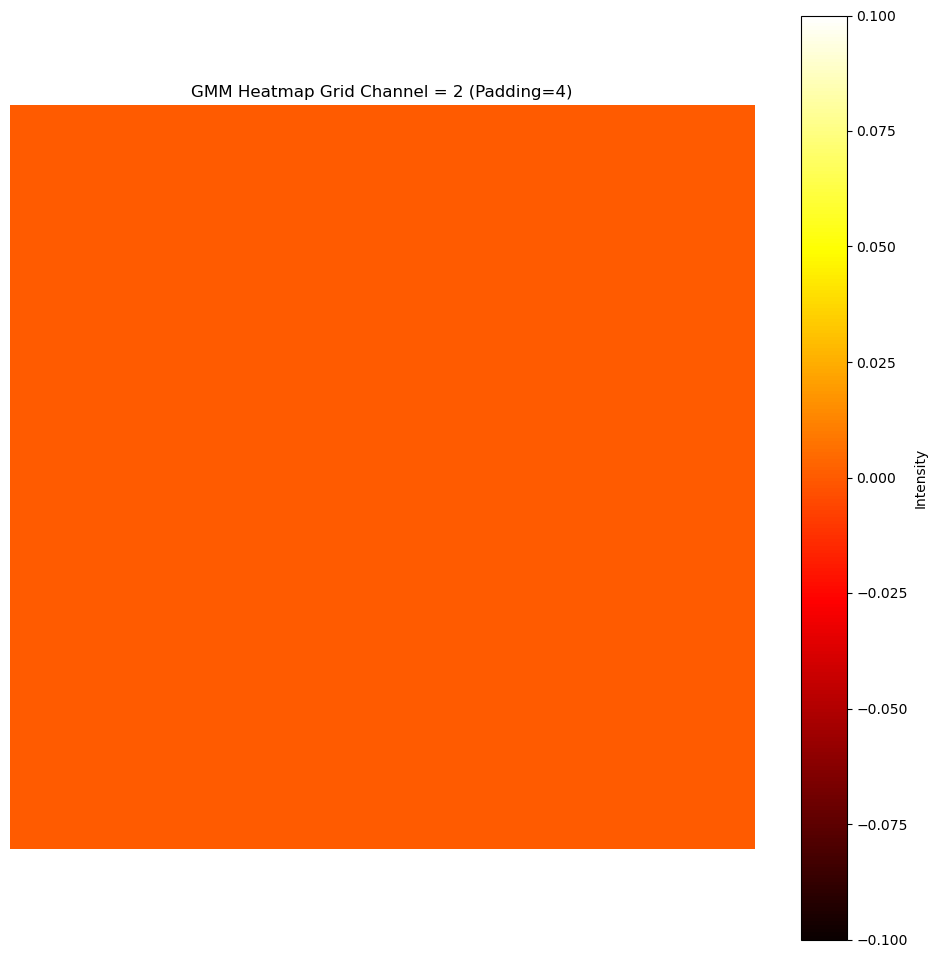

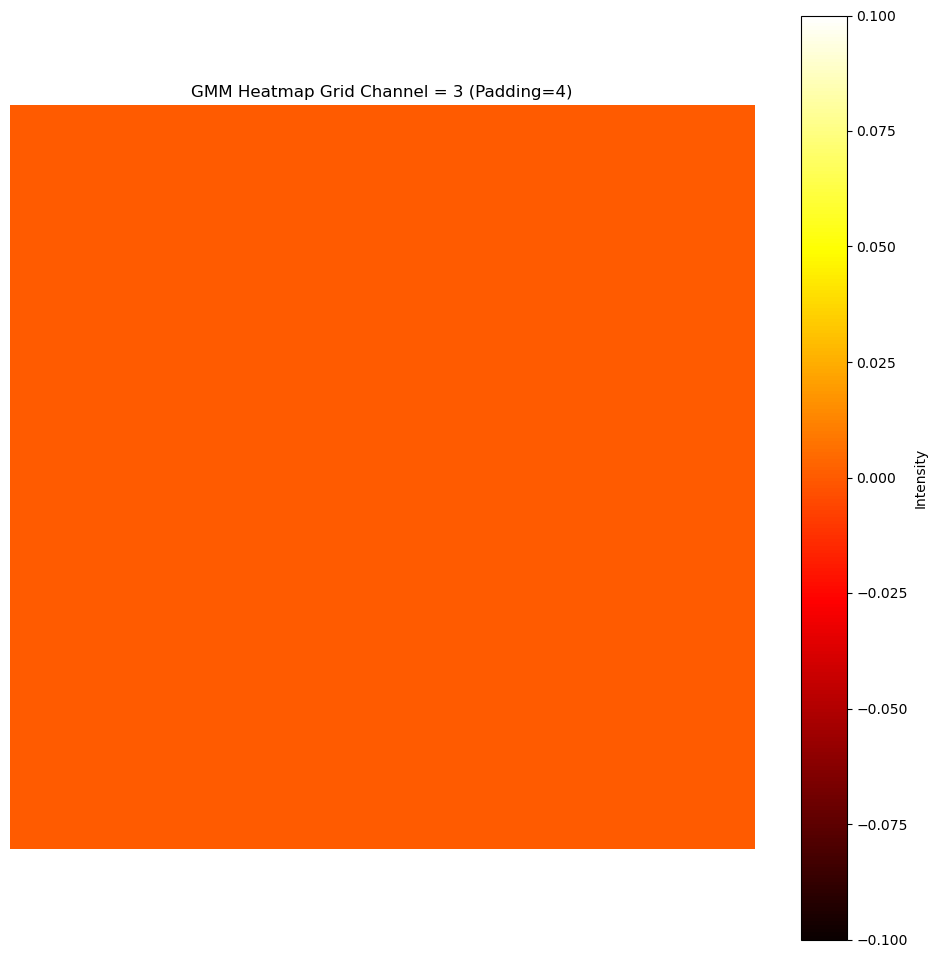

In [21]:
display_gmm_heatmaps_v2(batch[1])

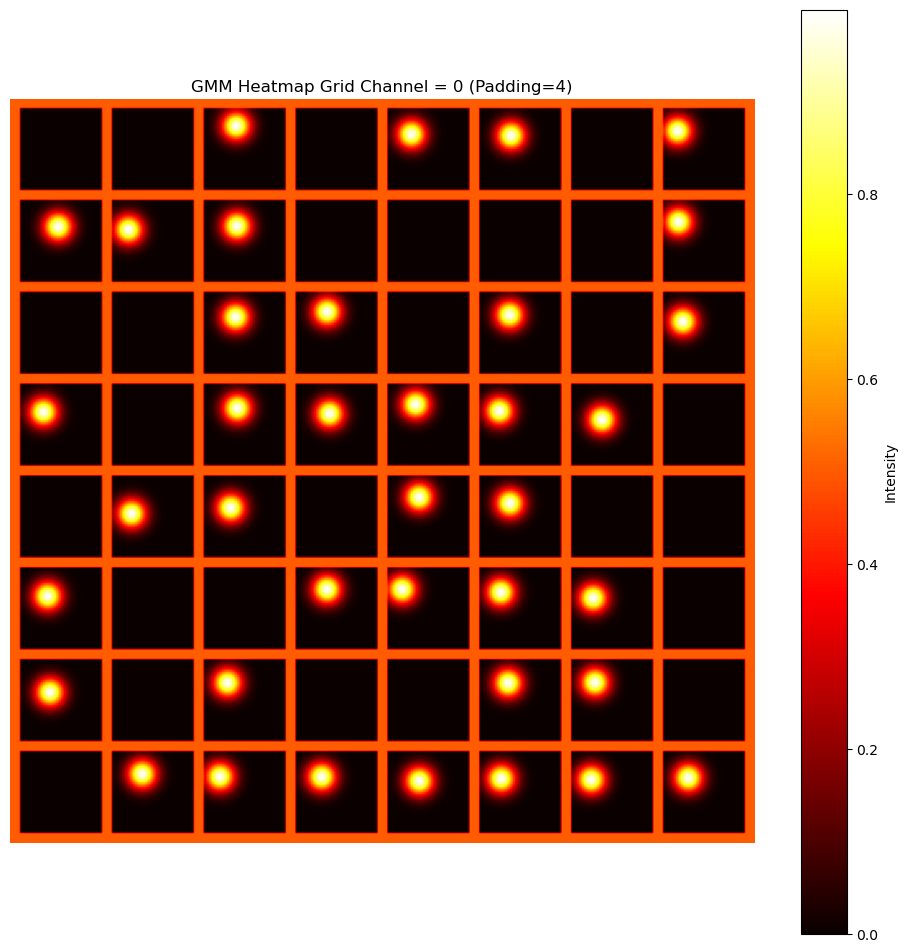

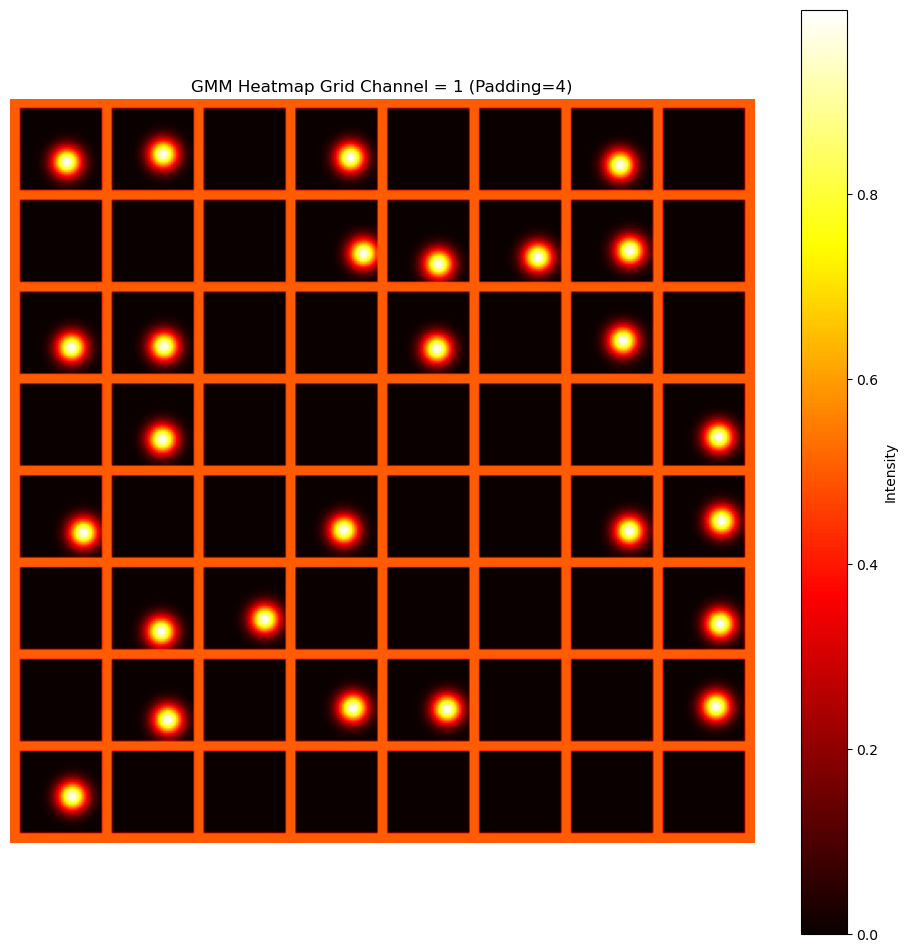

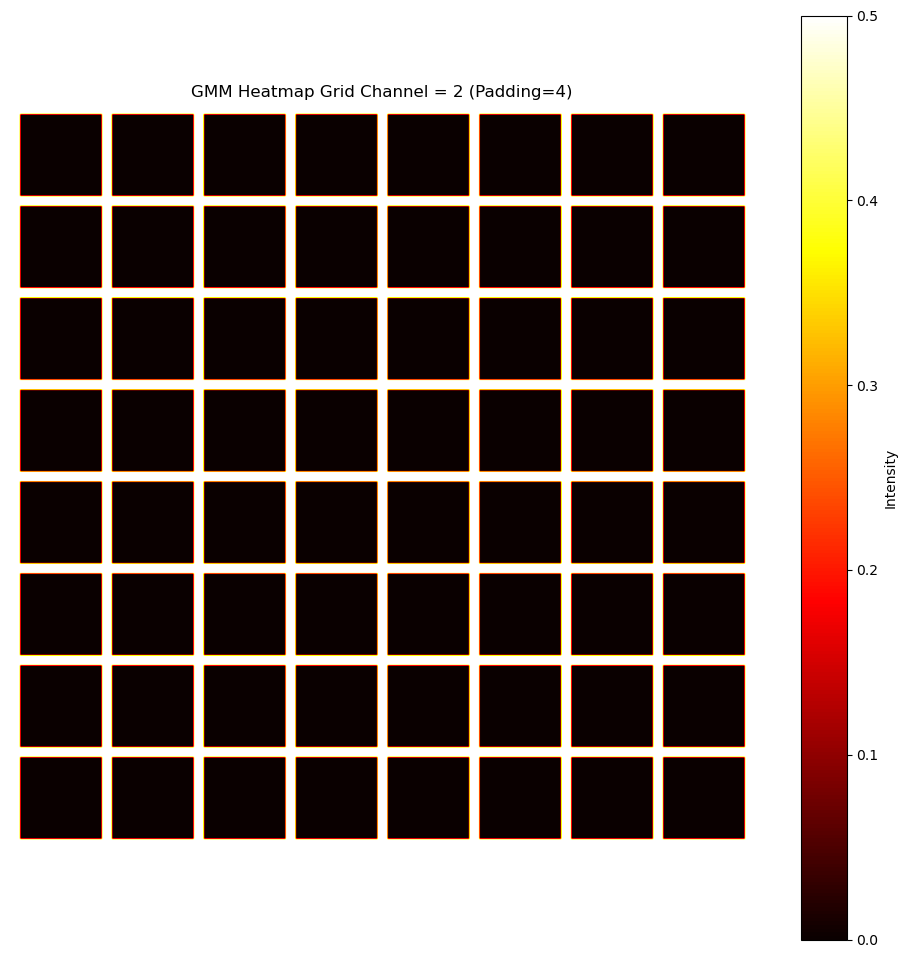

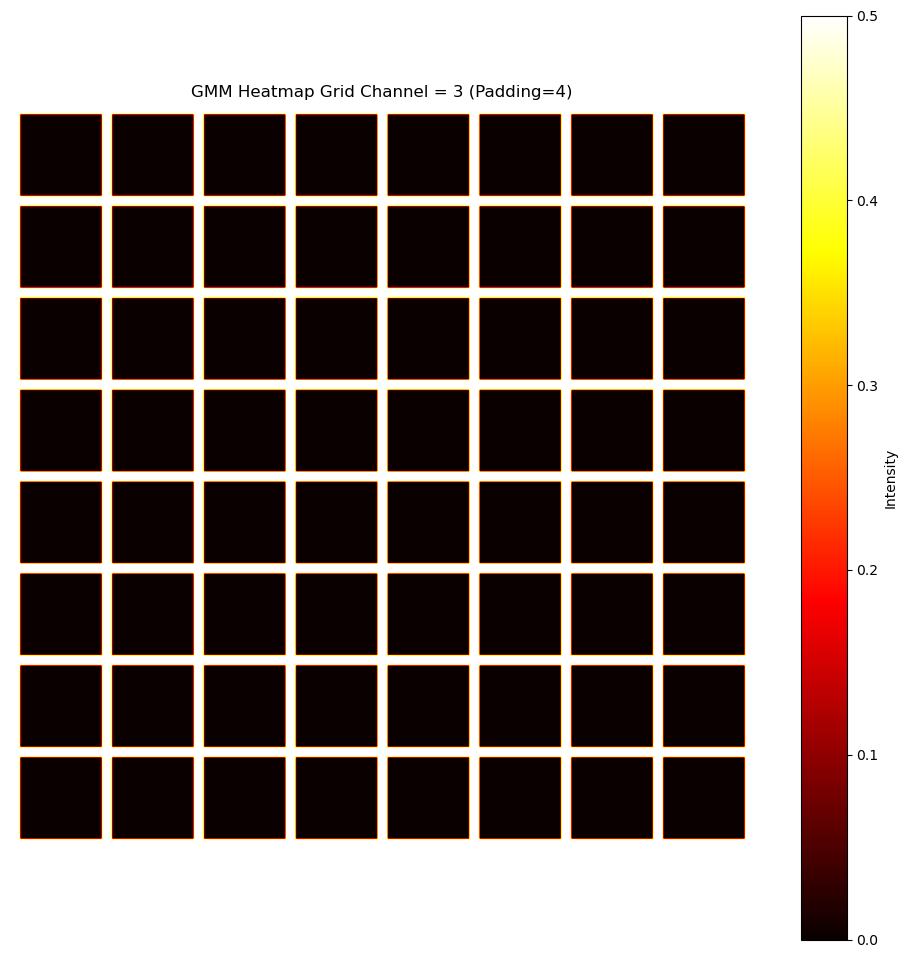

In [22]:
display_gmm_heatmaps_v2(batch)